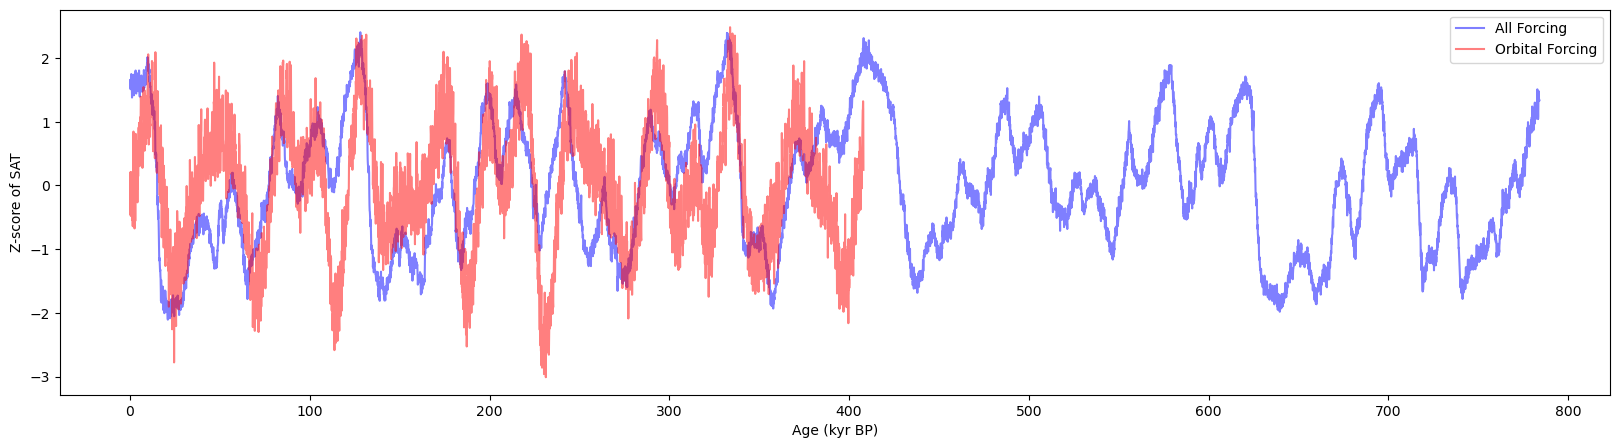

In [37]:
import xarray as xr

ds_orb=xr.open_dataset(r"E:\loveclim_data\loveclim_se_orbital_only_atm.nc")
ds_orb = ds_orb.rename({'t2m': 'sat'})
# rename the time to age
ds_orb = ds_orb.rename({'mtime': 'age'})



ds_all = xr.open_dataset('E:/loveclim_data/loveclim_784k_atm.nc')

ds_all = ds_all.rename({'t2m': 'sat'})
# rename the time to age
ds_all = ds_all.rename({'mtime': 'age'})

import matplotlib.pyplot as plt
from scipy.stats import zscore

plt.figure(figsize=(20, 5))
plt.plot(ds_all['age'].values, zscore(ds_all['sat'].isel(lat=30, lon=0).values), label='All Forcing', color='blue', alpha=0.5)
plt.plot(ds_orb['age'].values, zscore(ds_orb['sat'].isel(lat=30, lon=0).values), label='Orbital Forcing', color='red', alpha=0.5)
plt.xlabel('Age (kyr BP)')
plt.ylabel('Z-score of SAT')
# plt.title('Z-score of SAT at 30°N, 0°E')
plt.legend()


Original age max: 408.0
Original age min: 0.1


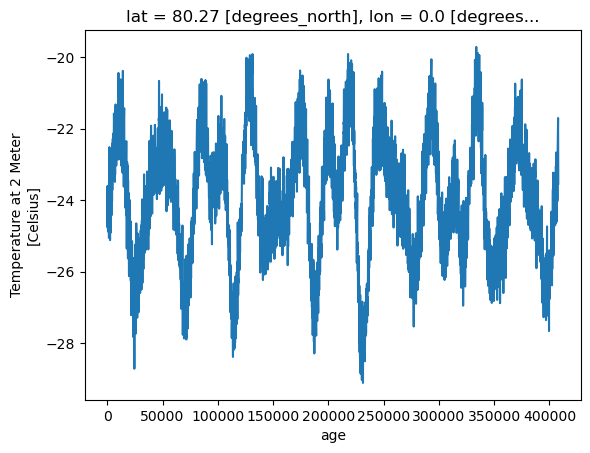

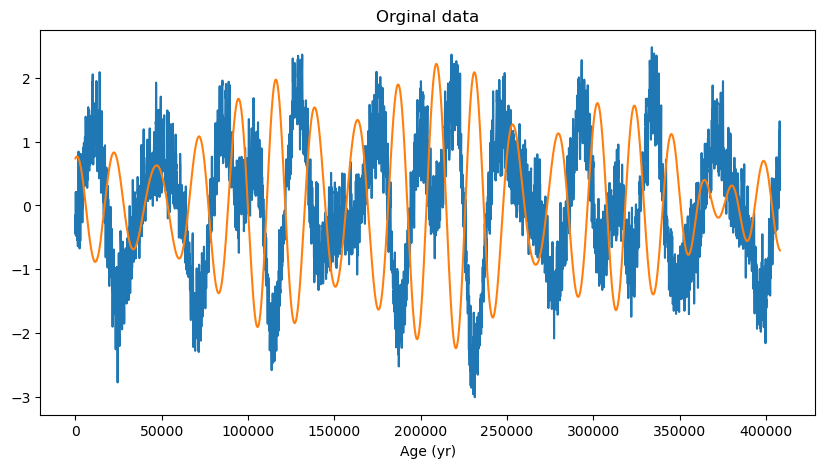

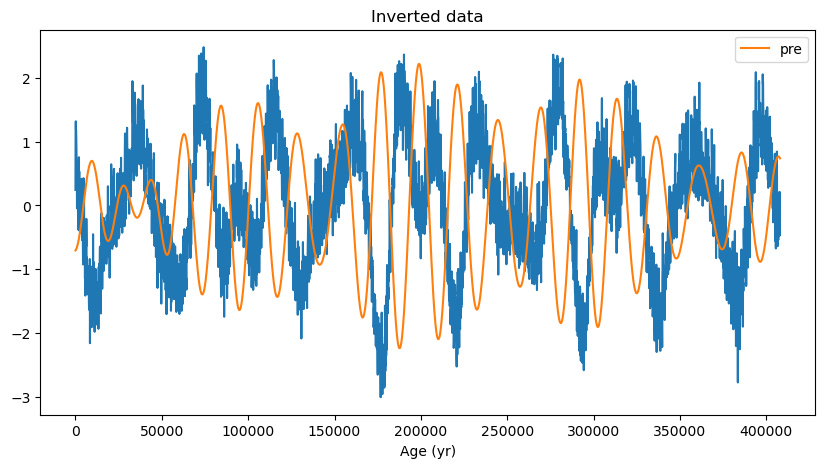

In [1]:
# import pre_800.csv from /inso_data
import pandas as pd

# Read the file into a DataFrame
df_pre = pd.read_csv(
    r"D:\VScode\Inso_LGMR\inso_data\pre_800.txt", 
    sep='\s+',       # '\s+' means "split on any whitespace"
    header=None,     # or specify a row number if there's a header
    engine='python'
)


df_pre.iloc[:, 0] = df_pre.iloc[:, 0].abs() * 1000

# Rename the columns
df_pre.columns = ['age', 'pre']

df_pre = df_pre[(df_pre['age'] >= 100) & (df_pre['age'] <= 408000)]



# load loveclim_se_orbital_only_atm.nc from E:\loveclim_data
import xarray as xr

ds=xr.open_dataset(r"E:\loveclim_data\loveclim_se_orbital_only_atm.nc")
ds

ds = ds.rename({'t2m': 'sat'})
# rename the time to age
ds = ds.rename({'mtime': 'age'})

print('Original age max:', ds['age'].max().values)
print('Original age min:', ds['age'].min().values)


# # multiply age by 1000
age_yr = ds['age'] * 1_000    
# age_yr = age_yr.max() - age_yr 
ds = ds.assign_coords(age=age_yr)                 



ds

# # # convert the sat to degrees C
# # ds['sat'] = ds['sat'] - 273.15

ds = ds[['sat']]
ds
ds['sat'].isel(lat=30, lon=0).plot()

# plot a record from the ds_sat at given lat and lon
import matplotlib.pyplot as plt
from scipy.stats import zscore

plt.figure(figsize=(10, 5))
plt.plot(ds['age'].values, zscore(ds['sat'].isel(lat=30, lon=0).values))
# plot the pre_800.csv data
plt.plot(df_pre['age'], zscore(df_pre['pre']), label='pre')
plt.title('Orginal data')
plt.xlabel('Age (yr)')



age_yr = age_yr.max() - age_yr                 
ds = ds.assign_coords(age=age_yr)
df_pre['age'] = df_pre['age'] * -1 + 408000

plt.figure(figsize=(10, 5))
plt.plot(ds['age'].values, zscore(ds['sat'].isel(lat=30, lon=0).values))
# plot the pre_800.csv data
plt.plot(df_pre['age'], zscore(df_pre['pre']), label='pre')
plt.title('Inverted data')
plt.xlabel('Age (yr)')
plt.legend()


(array([  12.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0., 4043.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
          24.]),
 array([ 99.96875   ,  99.96921539,  99.96968842,  99.97015381,
         99.97062683,  99.97109222,  99.97156525,  99.97203064,
         99.97250366,  99.97296906,  99.97343445,  99.97390747,
         9

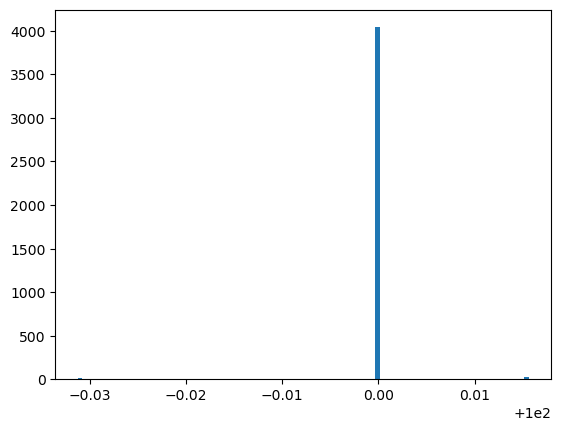

In [ ]:
import numpy as np

# age_diff=np.diff(ds['age'].values)
# # plot hist
# plt.hist(age_diff, bins=100)


In [45]:
df_pre.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4080 entries, 3920 to 7999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     4080 non-null   float64
 1   pre     4080 non-null   float64
dtypes: float64(2)
memory usage: 95.6 KB


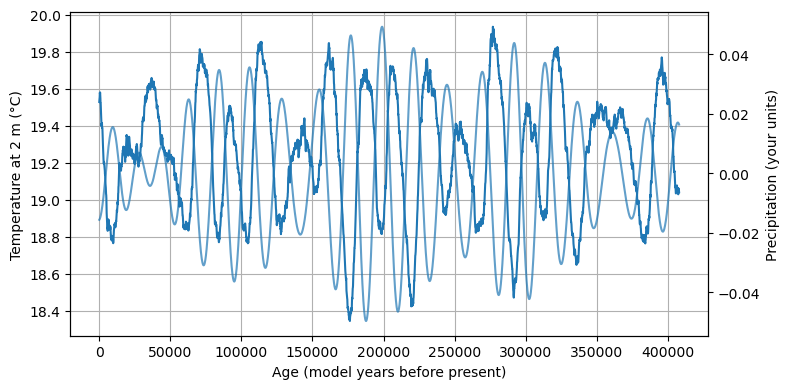

In [2]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

def smooth_sat(ds: xr.Dataset, lat_val: float, lon_val: float,
               window: int = 10, var: str = "sat") -> pd.Series:
    """
    Extract `var` at the nearest (lat, lon) grid point and apply a centred
    moving-average smoothing with `window` points.  No NaNs appear at the edges
    thanks to min_periods=1.

    Returns
    -------
    pd.Series
        Index is `age`, values are the smoothed variable.
    """
    # 1. pull the 1-D time series as a pandas Series
    s = (ds[var]
         .sel(lat=lat_val, lon=lon_val, method="nearest")
         .to_series())          # index is automatically the 'age' coordinate
    
    # 2. centred rolling mean – edges are filled with progressively smaller windows
    return s.rolling(window=window, center=True, min_periods=1).mean()


smoothed_sat = smooth_sat(ds, lat_val=30, lon_val=0, window=10)

# Align with precipitation: make sure both are indexed by the same 'age' axis
pre_series = df_pre.set_index("age")["pre"]
combined     = pd.concat([smoothed_sat.rename("sat_smoothed"), pre_series], axis=1)

# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(combined.index, combined["sat_smoothed"], label="SAT (°C, 10-pt MA)")
ax1.set_xlabel("Age (model years before present)")
ax1.set_ylabel("Temperature at 2 m (°C)")
ax1.grid(True)

# secondary y-axis for precipitation (or use the same axis if units are comparable)
ax2 = ax1.twinx()
# ax2.plot(combined.index, combined["pre"], label="Precipitation", alpha=0.7)
ax2.plot(df_pre['age'], df_pre['pre'], label="precession", alpha=0.7)
ax2.set_ylabel("Precipitation (your units)")

# tidy up the legend
# lines  = ax1.get_lines() + ax2.get_lines()
# labels = [l.get_label() for l in lines]
# ax1.legend(lines, labels, loc="upper right")

plt.tight_layout()
plt.show()


Length of df_ccm: 4080


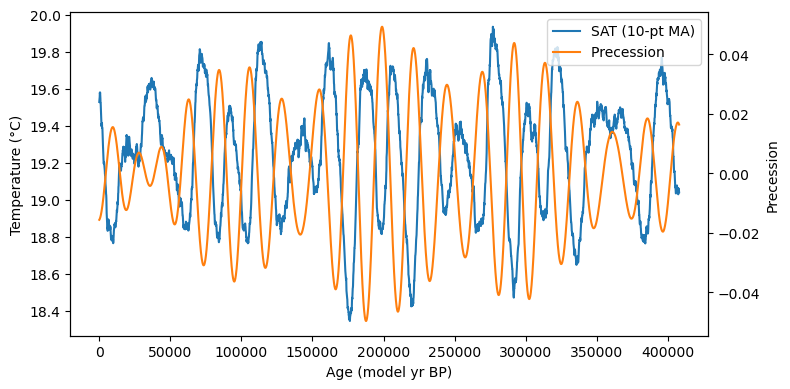

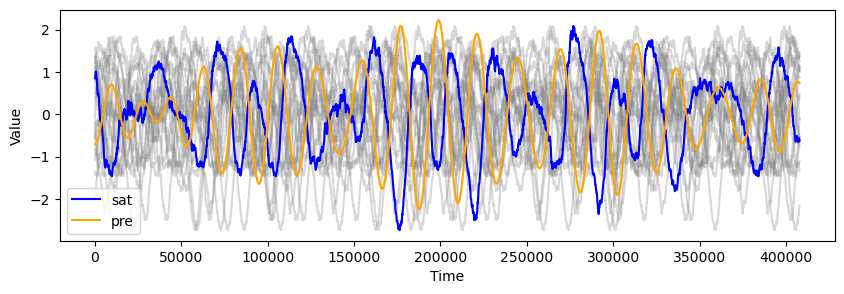

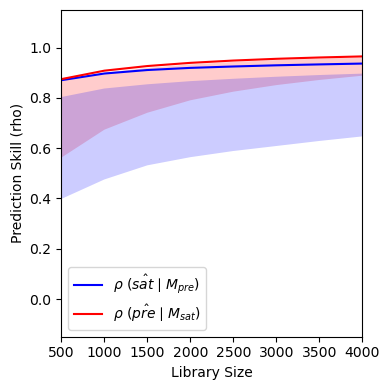

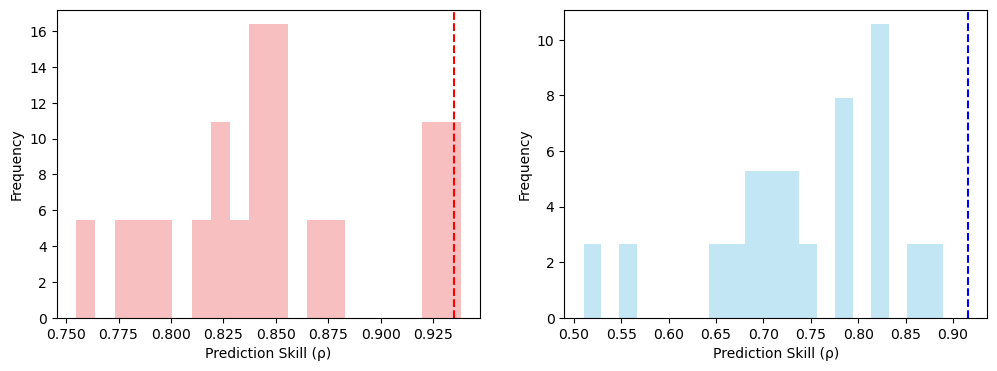

Significant SAT ➜ Precipitation causality? : True
Non-significant Precipitation ➜ SAT?       : True


In [ ]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pyEDM import CCM      # make sure pyEDM is installed
from toolbox import significant_test as st
import importlib
importlib.reload(st)


# ------------------------------------------------------------------
# 1.  helper: centred moving–average that keeps the edges intact
# ------------------------------------------------------------------
def smooth_sat(ds: xr.Dataset, lat_val: float, lon_val: float,
               window: int = 10, var: str = "sat") -> pd.Series:
    """
    Return a pandas Series containing `var` at the nearest grid point
    to (lat_val, lon_val), smoothed with a centred `window`-point
    moving average (no NaNs at either end).
    """
    raw = (ds[var]
           .sel(lat=lat_val, lon=lon_val, method="nearest")
           .to_series())            # index = the 'age' coordinate

    return raw.rolling(window=window, center=True, min_periods=1).mean()

# ------------------------------------------------------------------
# 2.  smooth the SAT record at (30 N, 0 E)
# ------------------------------------------------------------------
sat_smooth = smooth_sat(ds, lat_val=30, lon_val=0, window=10)

# sanity-check:  the two “age” axes must match
assert np.allclose(sat_smooth.index, df_pre["age"].values), "age axes differ!"

# ------------------------------------------------------------------
# 3.  assemble the CCM input DataFrame
#     (columns = age | sat | pre   in that order)
# ------------------------------------------------------------------
df_ccm = pd.DataFrame({
    "age": df_pre["age"].values,
    "sat": sat_smooth.values,
    "pre": df_pre["pre"].values
})

# print the length of the df_ccm
print("Length of df_ccm:", len(df_ccm))
# ------------------------------------------------------------------
# 4.  quick visual check
# ------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(df_ccm["age"], df_ccm["sat"], label="SAT (10-pt MA)")
ax1.set_xlabel("Age (model yr BP)")
ax1.set_ylabel("Temperature (°C)")
ax2 = ax1.twinx()
ax2.plot(df_ccm["age"], df_ccm["pre"], color="tab:orange", label="Precession ")
ax2.set_ylabel("Precession")
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc="upper right")
plt.tight_layout(); plt.show()

# ------------------------------------------------------------------
# 5.  run the causality / significance pipeline
# ------------------------------------------------------------------
ccm_out, ensemble_ccm, (sig_satxmappre, sig_prexmapsat) = (
    st.ccm_significance_test_v2_df(
        df_input   = df_ccm,
        E          = 5,      # embedding dimension
        tau        = -8,     # lag (negative = “past” influences “future”)
        n_ran      = 20,     # size of surrogate ensemble
        libSizes   = "500 1000, 1500 2000 2500 3000 3500 4000",
        Tp         = 0,
        sample     = 20,
        random     = True,
        showPlot   = True    # gives you: time-series plot + CCM rho plot + histograms
    )
)

print("SAT xmap Pre causality? :", sig_satxmappre)
print("Pre xmap SAT?       :", sig_prexmapsat)
